# Chapter 24 — Strain Gage Characteristics
### *Modern Strain Gage Technology* — Companion Notebook

A strain gage's datasheet is a column of numbers, and two of them — how much power it dissipates and how much it drifts with temperature — quietly decide whether a measurement can be trusted.

Companion notebook to Chapter 24 — Strain Gage Characteristics.

Selecting a strain gage involves more than choosing a resistance and gage factor. The excitation voltage, gage resistance, and thermal conductivity of the specimen material together determine how much power is dissipated in the gage itself — and excessive self-heating raises the gage temperature above the specimen temperature, introducing a thermal gradient that produces thermal output and, in extreme cases, damages the bond or the gage alloy.

The rule is straightforward: gage power dissipation must stay within limits set by the specimen's ability to conduct heat away. For metals with high thermal conductivity, up to 10 mW is generally acceptable. For composites and plastics, the limit drops to 1 mW or less. For foam and elastomers, it may be as low as 0.1 mW. The table below maps excitation voltage and gage resistance to dissipated power in a quarter-bridge circuit (where the gage dissipates $V_{ex}^2 / 4R_g$), flagging conditions that require reduced excitation or a higher-resistance gage.

The second half turns to *thermal output* — the strain a self-temperature-compensated gage indicates when the temperature changes but no load is applied — and reproduces Figure 24.1 of the chapter from two manufacturer-published curves.

**This notebook demonstrates:**
1. **Self-heating power** vs. excitation voltage and gage resistance — with an OK / CAUTION / HIGH classification.
2. **Thermal output** of two real STC-06 gages — the published polynomials for a Karma and a constantan grid, compared on the same substrate (Figure 24.1).

In [1]:
# !pip install numpy matplotlib
import os

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

---
## 1 — Self-Heating Power Check

Power dissipated in the gage is P = V²_ex / (4R_g), where the factor of 4 accounts for the quarter-bridge voltage divider — only one quarter of the excitation voltage appears across the gage. Higher excitation improves the bridge output signal but increases self-heating proportionally with V². Higher gage resistance reduces heating for the same excitation but also reduces the output signal, so the tradeoff is always between sensitivity and thermal loading.

The table classifies combinations as OK (≤10 mW), CAUTION (10–50 mW), or HIGH (>50 mW). In practice, the OK threshold applies to metals with good thermal contact between gage and specimen. For composites, the threshold is ten times lower. When a test requires simultaneous high sensitivity and low self-heating — transducer design, for example — the solution is usually a higher-resistance gage (1000 Ω or greater) at a modest excitation voltage (2–3 V).

In [2]:
# Self-heating limits (mW) and the conditions we sweep.
QUARTER_BRIDGE_DIVISOR = 4          # gage sees V_ex/2, so P = V_ex^2 / (4 R_g)
OK_LIMIT_MW = 10.0                  # acceptable on metals with good thermal contact
CAUTION_LIMIT_MW = 50.0            # borderline; reduce V_ex or raise R_g above this

EXCITATION_VOLTAGES_V = [1, 2, 5, 10]
GAGE_RESISTANCES_OHM = [120, 350, 1000]


def gage_power_mW(V_ex, R_g):
    """Power dissipated in a single quarter-bridge gage, in milliwatts.

    Only V_ex/2 appears across the active gage in a quarter bridge, so the
    dissipation is V_ex**2 / (4 * R_g). Inputs are volts and ohms.
    """
    return V_ex**2 / (QUARTER_BRIDGE_DIVISOR * R_g) * 1000.0


def heating_status(P_mW):
    """Classify gage self-heating as OK, CAUTION, or HIGH against the metal limits."""
    if P_mW <= OK_LIMIT_MW:
        return "OK"
    if P_mW <= CAUTION_LIMIT_MW:
        return "CAUTION"
    return "HIGH"


print("SELF-HEATING POWER CHECK")
print(f"{'Vex (V)':>8}  {'Rg (Ω)':>8}  {'P_gage (mW)':>14}  {'Status':>10}")
for V_ex in EXCITATION_VOLTAGES_V:
    for R_g in GAGE_RESISTANCES_OHM:
        P_mW = gage_power_mW(V_ex, R_g)
        print(f"{V_ex:>8}  {R_g:>8}  {P_mW:>14.2f}  {heating_status(P_mW):>10}")
    print()
print("Rule: ≤10 mW on metals, ≤1 mW on composites/plastics, ≤0.1 mW on foam/rubber")

SELF-HEATING POWER CHECK
 Vex (V)    Rg (Ω)     P_gage (mW)      Status
       1       120            2.08          OK
       1       350            0.71          OK
       1      1000            0.25          OK

       2       120            8.33          OK
       2       350            2.86          OK
       2      1000            1.00          OK

       5       120           52.08        HIGH
       5       350           17.86     CAUTION
       5      1000            6.25          OK

      10       120          208.33        HIGH
      10       350           71.43        HIGH
      10      1000           25.00     CAUTION

Rule: ≤10 mW on metals, ≤1 mW on composites/plastics, ≤0.1 mW on foam/rubber


---
## 2 — Figure 24.1: Thermal Output of Two Real Gages

Thermal output is the strain a bonded gage indicates when the temperature changes and no mechanical load is applied. In a self-temperature-compensated (STC) gage the grid alloy is processed so that its temperature coefficient of resistance offsets the differential expansion between grid and substrate. The cancellation is close to exact only in a band around the reference temperature; outside that band a deterministic residual grows, and how fast it grows depends on the alloy.

The two curves below are **published polynomials for specific gages**, in °C, with output in με. Both carry **STC code 06** — both are compensated for steel — and both are referenced to zero at +24 °C, so the comparison is like for like and the only substantial difference between them is the grid alloy:

| Gage | Grid alloy | Fit order | Zero |
|---|---|---|---|
| `C5K-06-S5145-350/39F` | K-alloy (Karma) | 5th | +24 °C |
| `CEA-06-250UW-350` | A-alloy (constantan) | 5th | +24 °C |

**Neither curve is flat, and neither is a parabola.** The constantan gage holds within a few microstrain only between about 10 and 50 °C. Outside that narrow band it falls away hard — to −144 με near 150 °C, and to −545 με at −50 °C. The Karma gage rises to a broad maximum of about +61 με near 110 °C and then declines gently, staying inside a **26 με** band from 50 to 175 °C where the constantan gage swings through **141 με** over the same span. At −50 °C the Karma gage reads −205 με against the constantan gage's −545.

That is the whole case for K-alloy in transducer work and wide-temperature installations: not a lower thermal output at the reference, but a much wider band over which the output stays small.

`reference_to()` below re-zeros either curve to any balance temperature, which is what you need when the bridge is balanced somewhere other than the certificate's +24 °C reference.


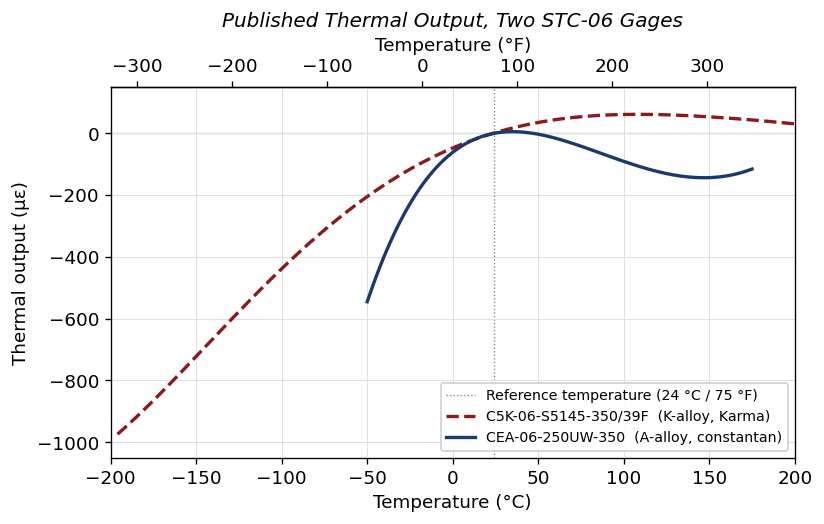

Saved → ..\src\media\ch24\fig24_1_thermal_output.png

THERMAL OUTPUT (με), BOTH REFERENCED TO +24 C
   T (C)    C5K-06 (K-alloy)    CEA-06 (A-alloy)
    -196              -974.5                   —
    -150              -722.6                   —
    -100              -438.8                   —
     -50              -205.4              -544.9
     -25              -116.9              -227.6
       0               -48.1               -61.2
      24                 0.0                 0.0
      50                34.5                -2.7
      75                53.0               -41.5
     100                60.3               -90.6
     125                59.3              -130.1
     150                52.7              -143.2
     175                42.5              -115.4

Spread over +50 to +175 C:
  C5K-06 (K-alloy):     26 ue (+35 to +61)
  CEA-06 (A-alloy):    141 ue (-144 to -3)

C5K-06: slope at +24 C = +1.66 ue/C (+17 ue for a 10 C excursion)
CEA-06: slope at +24 C = +1.05 ue

In [3]:
# ── Published thermal-output polynomials (°C in, με out) ──────────────
# Manufacturer curves for two specific gages, reproduced verbatim. Both carry
# STC code 06 (compensated for steel) and both are referenced to zero at
# +24 °C, so the pair isolates the effect of the grid alloy.
#
# A thermal-output curve is lot-, substrate-, and installation-specific; never
# substitute one gage's curve for another's.

def thermal_output_c5k(T):
    """C5K-06-S5145-350/39F — K-alloy (Karma) grid, STC 06.

    Published fifth-order fit. T in °C, thermal output in με.
    """
    return (-4.76e1 + 2.36e0 * T - 1.52e-2 * T**2 + 1.64e-5 * T**3
            + 1.09e-7 * T**4 - 2.86e-10 * T**5)


def thermal_output_cea(T):
    """CEA-06-250UW-350 — A-alloy (constantan) grid, STC 06.

    Published fifth-order fit. T in °C, thermal output in με.
    """
    return (-6.16e1 + 4.29e0 * T - 8.27e-2 * T**2 + 4.50e-4 * T**3
            - 9.27e-7 * T**4 + 1.13e-9 * T**5)


def reference_to(curve, T, T_balance):
    """Re-zero a thermal-output curve to an arbitrary balance temperature.

    A published curve reads zero at its certificate reference. If the bridge
    is balanced somewhere else, subtract the curve's value there — thermal
    output is always measured from wherever you zeroed.
    """
    return curve(T) - curve(T_balance)


# ── Validity ranges ──────────────────────────────────────────
# Each polynomial is a fit over the range its lot was characterized on. A
# fifth-order fit diverges quickly outside that range: the CEA curve turns
# sharply upward past about 200 °C and means nothing there. Draw each curve
# only where it is valid. The K-alloy curve runs down to -196 °C (-320 °F),
# liquid-nitrogen temperature.
T_REF_C = 24.0                       # +24 °C / +75 °F certificate reference
T_c5k = np.linspace(-196, 200, 500)  # °C — K-alloy, down to LN2 (-320 °F)
T_cea = np.linspace(-50, 175, 500)   # °C — CEA series upper service limit

eps_c5k = thermal_output_c5k(T_c5k)
eps_cea = thermal_output_cea(T_cea)

c2f = lambda c: c * 9 / 5 + 32
f2c = lambda f: (f - 32) * 5 / 9

# ── Figure ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.axhline(0, color='0.75', linewidth=0.8, zorder=1)
ax.axvline(T_REF_C, color='0.5', linewidth=0.8, linestyle=':', zorder=1,
           label=f'Reference temperature ({T_REF_C:.0f} °C / 75 °F)')

ax.plot(T_c5k, eps_c5k, color='#8b1a1a', linewidth=2.0, linestyle='--',
        label='C5K-06-S5145-350/39F  (K-alloy, Karma)')
ax.plot(T_cea, eps_cea, color='#1a3a6b', linewidth=2.0,
        label='CEA-06-250UW-350  (A-alloy, constantan)')

ax.set_xlabel('Temperature (°C)', fontsize=11)
ax.set_ylabel('Thermal output (με)', fontsize=11)
ax.set_title('Published Thermal Output, Two STC-06 Gages', style='italic', fontsize=12)
ax.set_xlim(-200, 200)
ax.set_ylim(-1050, 150)
ax.legend(fontsize=8.5, framealpha=0.9, loc='lower right')
ax.grid(True, color='0.88', linewidth=0.6)

secax = ax.secondary_xaxis('top', functions=(c2f, f2c))
secax.set_xlabel('Temperature (°F)', fontsize=11)

fig.tight_layout()

out_path = os.path.join('..', 'src', 'media', 'ch24', 'fig24_1_thermal_output.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
fig.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {out_path}")

# ── What the curves say, in numbers ───────────────────────────────
print()
print("THERMAL OUTPUT (με), BOTH REFERENCED TO +24 C")
print(f"{'T (C)':>8}  {'C5K-06 (K-alloy)':>18}  {'CEA-06 (A-alloy)':>18}")
for T_pt in (-196, -150, -100, -50, -25, 0, 24, 50, 75, 100, 125, 150, 175):
    k = reference_to(thermal_output_c5k, T_pt, T_REF_C)
    # CEA fit is valid only from -50 °C up; leave it blank below that.
    a = (f"{reference_to(thermal_output_cea, T_pt, T_REF_C):>18.1f}"
         if T_pt >= T_cea[0] else f"{'—':>18}")
    print(f"{T_pt:>8}  {k:>18.1f}  {a}")

# The alloy's real advantage is band width, not the value at the reference.
band = np.linspace(50, 175, 400)
k_band = thermal_output_c5k(band)
a_band = thermal_output_cea(band)
print()
print(f"Spread over +50 to +175 C:")
print(f"  C5K-06 (K-alloy): {k_band.max() - k_band.min():6.0f} ue "
      f"({k_band.min():+.0f} to {k_band.max():+.0f})")
print(f"  CEA-06 (A-alloy): {a_band.max() - a_band.min():6.0f} ue "
      f"({a_band.min():+.0f} to {a_band.max():+.0f})")

h = 0.5
print()
for name, curve in (('C5K-06', thermal_output_c5k), ('CEA-06', thermal_output_cea)):
    slope = (curve(T_REF_C + h) - curve(T_REF_C - h)) / (2 * h)
    print(f"{name}: slope at +24 C = {slope:+.2f} ue/C "
          f"({slope * 10:+.0f} ue for a 10 C excursion)")


---
## Where to take this next

The two calculations above are deliberately small so you can extend them into a working selection tool:

1. **Add the composite and elastomer limits to the power check.** Right now the table classifies against the 10 mW metal limit only. Pass the applicable limit (10 / 1 / 0.1 mW) into `heating_status` as an argument and reprint the table for a carbon-fiber or foam specimen — you will see why high-resistance gages and low excitation become mandatory off metal.

2. **Convert thermal output into a stress error, then into a temperature specification.** Both curves above are in με. Multiply the residual over your service temperature range by Young's modulus for the specimen to get the equivalent stress error, and compare it against the margin you are defending. Run the same calculation backwards and it tells you how tightly the test environment has to be controlled — usually the cheaper of the two fixes.

3. **Turn the gage-factor temperature coefficient into a gain-error curve.** Using the $+0.9\%$ per 100 °C figure from Table 24.1, plot the sensitivity error versus temperature and overlay it on the thermal-output plot — a direct picture of the chapter's central distinction between a *gain* error (slope) and a *zero* offset (thermal output).